# Acquiring, Clipping, and Analyzing Sea Surface Salinity Data

In this activity, you will:
1. Download sea surface salinity (SSS) data from NASA Earth Data for **2015** and **2022**
2. Merge monthly files into annual datasets
3. Create a custom study area shapefile
4. Clip data to your study area
5. Perform statistical analysis comparing the two years

---

## Prerequisites

You need a **free NASA Earth Data account**. If you don't have one:
1. Go to https://urs.earthdata.nasa.gov/
2. Click **Register** and complete the form
3. Verify your email

---

## Part 1: Setup

Run the two cells below to install packages and import libraries. The install takes about 1-2 minutes.

In [3]:
# Install packages not pre-installed on Google Colab
!pip install -q earthaccess cartopy rioxarray netCDF4 h5netcdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.2/71.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 77.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
datasets 4.0.0 requires fs

In [4]:
import numpy as np
import pandas as pd
import os
import time
import xarray as xr
import geopandas as gpd
import rioxarray
import earthaccess
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from shapely.geometry import Polygon, box

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 2: NASA Earth Data Authentication

Run the cell below. You will be prompted to enter your NASA Earth Data **username** and **password**.

In [5]:
auth = earthaccess.login(strategy="interactive")

if auth.authenticated:
    print("Successfully logged in to NASA Earthdata!")
else:
    raise RuntimeError(
        "Login failed. Check your credentials and try again.\n"
        "Register at https://urs.earthdata.nasa.gov/ if needed."
    )

Enter your Earthdata Login username: jacobspier1
Enter your Earthdata password: ··········
Successfully logged in to NASA Earthdata!


## Part 3: Download Sea Surface Salinity Data

The dataset is **Multi-Mission Optimally Interpolated Sea Surface Salinity (OISSS)**:
- **Dataset ID:** OISSS_L4_multimission_monthly_v2
- **Resolution:** 0.25 x 0.25 degree global grid
- **DOI:** 10.5067/SMP20-4UMCS

We download 12 monthly files for each year. This takes a few minutes.

In [6]:
# Search for granules
# Use extended end dates (Jan 1 of next year) to avoid missing December
SHORT_NAME = "OISSS_L4_multimission_monthly_v2"

print("Searching for 2015 data...")
results_2015 = earthaccess.search_data(
    short_name=SHORT_NAME,
    temporal=("2015-01-01", "2016-01-01")
)
print(f"Found {len(results_2015)} granules for 2015")

print("\nSearching for 2022 data...")
results_2022 = earthaccess.search_data(
    short_name=SHORT_NAME,
    temporal=("2022-01-01", "2023-01-01")
)
print(f"Found {len(results_2022)} granules for 2022")

# Show what we found
print("\n2015 granules:")
for r in results_2015:
    links = r.data_links()
    print(f"  {os.path.basename(links[0]) if links else 'no link'}")

print("\n2022 granules:")
for r in results_2022:
    links = r.data_links()
    print(f"  {os.path.basename(links[0]) if links else 'no link'}")

Searching for 2015 data...
Found 13 granules for 2015

Searching for 2022 data...
Found 13 granules for 2022

2015 granules:
  OISSS_L4_multimission_global_monthly_v2.0_2015-01.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-02.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-03.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-04.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-05.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-06.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-07.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-08.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-09.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-10.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-11.nc
  OISSS_L4_multimission_global_monthly_v2.0_2015-12.nc
  OISSS_L4_multimission_global_monthly_v2.0_2016-01.nc

2022 granules:
  OISSS_L4_multimission_global_monthly_v2.0_2022-01.nc
  OISSS_L4_multimission_global_monthly_v2.0_2022-02.nc
  OISSS_L4_multimission_global_mon

In [7]:
def download_granules_reliably(results, output_dir, max_retries=3):
    """
    Download granules one at a time with retries.

    earthaccess.download() uses batch parallelism that aborts all remaining
    downloads if any single file fails. This function downloads one granule
    at a time so a single failure doesn't kill the rest.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Clear any partial files from previous failed attempts
    for f in output_dir.glob("*.nc"):
        if f.stat().st_size < 1000:  # tiny file = probably an error page
            print(f"  Removing corrupt/incomplete file: {f.name}")
            f.unlink()

    downloaded = []
    failed = []

    for i, granule in enumerate(results):
        links = granule.data_links()
        name = os.path.basename(links[0]) if links else f"granule_{i}"

        # Skip if already downloaded and file is reasonable size (>100KB)
        existing = output_dir / name
        if existing.exists() and existing.stat().st_size > 100_000:
            print(f"  [{i+1}/{len(results)}] {name} -- already exists, skipping")
            downloaded.append(str(existing))
            continue

        success = False
        for attempt in range(1, max_retries + 1):
            try:
                files = earthaccess.download([granule], str(output_dir))
                downloaded.extend([str(f) for f in files])
                print(f"  [{i+1}/{len(results)}] {name} -- OK")
                success = True
                break
            except Exception as e:
                print(f"  [{i+1}/{len(results)}] {name} -- attempt {attempt} failed: {e}")
                if attempt < max_retries:
                    time.sleep(2 * attempt)  # brief backoff

        if not success:
            print(f"  [{i+1}/{len(results)}] {name} -- FAILED after {max_retries} attempts")
            failed.append(name)

    return downloaded, failed

In [8]:
# Download 2015 data
download_dir_2015 = Path("Earth_Data/OISSS/2015")
print("=" * 50)
print("Downloading 2015 data...")
print("=" * 50)
downloaded_2015, failed_2015 = download_granules_reliably(results_2015, download_dir_2015)

print(f"\nDownloaded: {len(downloaded_2015)}, Failed: {len(failed_2015)}")
if failed_2015:
    print(f"Failed files: {failed_2015}")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  [1/13] OISSS_L4_multimission_global_monthly_v2.0_2015-01.nc -- OK


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

  [12/13] OISSS_L4_multimission_global_monthly_v2.0_2015-12.nc -- OK


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  [13/13] OISSS_L4_multimission_global_monthly_v2.0_2016-01.nc -- OK

Downloaded: 13, Failed: 0


In [9]:
# Download 2022 data
download_dir_2022 = Path("Earth_Data/OISSS/2022")
print("=" * 50)
print("Downloading 2022 data...")
print("=" * 50)
downloaded_2022, failed_2022 = download_granules_reliably(results_2022, download_dir_2022)

print(f"\nDownloaded: {len(downloaded_2022)}, Failed: {len(failed_2022)}")
if failed_2022:
    print(f"Failed files: {failed_2022}")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  [1/13] OISSS_L4_multimission_global_monthly_v2.0_2022-01.nc -- OK


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

  [12/13] OISSS_L4_multimission_global_monthly_v2.0_2022-12.nc -- OK


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  [13/13] OISSS_L4_multimission_global_monthly_v2.0_2023-01.nc -- OK

Downloaded: 13, Failed: 0


In [10]:
# Verify downloaded files
files_2015 = sorted(download_dir_2015.glob("*.nc"))
print(f"2015 files: {len(files_2015)}")
for f in files_2015:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}  ({size_mb:.1f} MB)")

files_2022 = sorted(download_dir_2022.glob("*.nc"))
print(f"\n2022 files: {len(files_2022)}")
for f in files_2022:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}  ({size_mb:.1f} MB)")

# Verify we have enough data to proceed
if len(files_2015) < 1 or len(files_2022) < 1:
    raise RuntimeError(
        "Download failed -- no files were retrieved. "
        "Check your Earthdata credentials and internet connection, then re-run the download cells."
    )

if len(files_2015) == 12 and len(files_2022) == 12:
    print("\nAll 24 files downloaded successfully!")
else:
    print(f"\nNote: Got {len(files_2015)} months for 2015 and {len(files_2022)} months for 2022.")
    print("The analysis will use all available months.")

2015 files: 13
  OISSS_L4_multimission_global_monthly_v2.0_2015-01.nc  (7.1 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-02.nc  (7.1 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-03.nc  (7.1 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-04.nc  (7.0 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-05.nc  (6.9 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-06.nc  (6.7 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-07.nc  (6.8 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-08.nc  (6.9 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-09.nc  (6.9 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-10.nc  (6.8 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-11.nc  (6.7 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2015-12.nc  (6.9 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2016-01.nc  (7.0 MB)

2022 files: 13
  OISSS_L4_multimission_global_monthly_v2.0_2022-01.nc  (7.1 MB)
  OISSS_L4_multimission_global_monthly_v2.0_2022-02.nc  (7.

## Part 4: Merge Monthly Files into Annual Datasets

Combine the monthly files for each year into a single NetCDF file.

In [11]:
# Merge 2015 monthly files
files_2015 = sorted(download_dir_2015.glob("*.nc"))
print(f"Merging {len(files_2015)} files for 2015...")

# Use h5netcdf engine -- more reliable on Colab than netcdf4 for open_mfdataset
ds_2015 = xr.open_mfdataset(
    [str(f) for f in files_2015],
    combine='by_coords',
    engine='h5netcdf'
)
print(ds_2015)

merged_path_2015 = Path("Earth_Data/SSS_2015_merged.nc")
ds_2015.to_netcdf(merged_path_2015)
print(f"\nSaved: {merged_path_2015}")

Merging 13 files for 2015...
<xarray.Dataset> Size: 539MB
Dimensions:                    (latitude: 720, longitude: 1440, time: 13)
Coordinates:
  * latitude                   (latitude) float32 3kB -89.88 -89.62 ... 89.88
  * longitude                  (longitude) float32 6kB -179.9 -179.6 ... 179.9
  * time                       (time) datetime64[ns] 104B 2015-01-16 ... 2016...
Data variables:
    sss                        (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_empirical_uncertainty  (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_formal_uncertainty     (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_climatology            (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_anomaly                (latitude, longitude, time) float64 108MB dask.array<chunksize

/usr/local/lib/python3.12/dist-packages/xarray/backends/netCDF4_.py:661: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  fill_value=fill_value,



Saved: Earth_Data/SSS_2015_merged.nc


In [12]:
# Merge 2022 monthly files
files_2022 = sorted(download_dir_2022.glob("*.nc"))
print(f"Merging {len(files_2022)} files for 2022...")

ds_2022 = xr.open_mfdataset(
    [str(f) for f in files_2022],
    combine='by_coords',
    engine='h5netcdf'
)
print(ds_2022)

merged_path_2022 = Path("Earth_Data/SSS_2022_merged.nc")
ds_2022.to_netcdf(merged_path_2022)
print(f"\nSaved: {merged_path_2022}")

Merging 13 files for 2022...
<xarray.Dataset> Size: 539MB
Dimensions:                    (latitude: 720, longitude: 1440, time: 13)
Coordinates:
  * latitude                   (latitude) float32 3kB -89.88 -89.62 ... 89.88
  * longitude                  (longitude) float32 6kB -179.9 -179.6 ... 179.9
  * time                       (time) datetime64[ns] 104B 2022-01-16 ... 2023...
Data variables:
    sss                        (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_empirical_uncertainty  (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_formal_uncertainty     (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_climatology            (latitude, longitude, time) float64 108MB dask.array<chunksize=(720, 1440, 1), meta=np.ndarray>
    sss_anomaly                (latitude, longitude, time) float64 108MB dask.array<chunksize

/usr/local/lib/python3.12/dist-packages/xarray/backends/netCDF4_.py:661: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  fill_value=fill_value,



Saved: Earth_Data/SSS_2022_merged.nc


In [13]:
# Examine both merged datasets
ds_2015 = xr.open_dataset("Earth_Data/SSS_2015_merged.nc")
ds_2022 = xr.open_dataset("Earth_Data/SSS_2022_merged.nc")

print("=== 2015 Merged Dataset ===")
print(f"Dimensions: {dict(ds_2015.dims)}")
print(f"Variables: {list(ds_2015.data_vars)}")
print(f"Time steps: {len(ds_2015.time)}")
print(f"Time range: {str(ds_2015.time.values[0])[:10]} to {str(ds_2015.time.values[-1])[:10]}")

print("\n=== 2022 Merged Dataset ===")
print(f"Dimensions: {dict(ds_2022.dims)}")
print(f"Variables: {list(ds_2022.data_vars)}")
print(f"Time steps: {len(ds_2022.time)}")
print(f"Time range: {str(ds_2022.time.values[0])[:10]} to {str(ds_2022.time.values[-1])[:10]}")

print("\n--- Variable details ---")
for var in ds_2015.data_vars:
    print(f"  {var}: dims={ds_2015[var].dims}, shape={ds_2015[var].shape}")

=== 2015 Merged Dataset ===
Dimensions: {'latitude': 720, 'longitude': 1440, 'time': 13}
Variables: ['sss', 'sss_empirical_uncertainty', 'sss_formal_uncertainty', 'sss_climatology', 'sss_anomaly']
Time steps: 13
Time range: 2015-01-16 to 2016-01-16

=== 2022 Merged Dataset ===
Dimensions: {'latitude': 720, 'longitude': 1440, 'time': 13}
Variables: ['sss', 'sss_empirical_uncertainty', 'sss_formal_uncertainty', 'sss_climatology', 'sss_anomaly']
Time steps: 13
Time range: 2022-01-16 to 2023-01-16

--- Variable details ---
  sss: dims=('latitude', 'longitude', 'time'), shape=(720, 1440, 13)
  sss_empirical_uncertainty: dims=('latitude', 'longitude', 'time'), shape=(720, 1440, 13)
  sss_formal_uncertainty: dims=('latitude', 'longitude', 'time'), shape=(720, 1440, 13)
  sss_climatology: dims=('latitude', 'longitude', 'time'), shape=(720, 1440, 13)
  sss_anomaly: dims=('latitude', 'longitude', 'time'), shape=(720, 1440, 13)


/tmp/ipykernel_7115/3717200062.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds_2015.dims)}")
/tmp/ipykernel_7115/3717200062.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds_2022.dims)}")


## Part 5: Create Your Study Area Shapefile

Choose an ocean region that interests you! Edit the coordinates below.

**Some suggestions:**

| Region | min_lon | min_lat | max_lon | max_lat |
|---|---|---|---|---|
| Gulf of Mexico | -98 | 18 | -80 | 31 |
| Caribbean Sea | -90 | 9 | -59 | 22 |
| Mediterranean Sea | -6 | 30 | 36 | 46 |
| Bay of Bengal | 78 | 5 | 95 | 23 |
| North Atlantic | -80 | 25 | -10 | 60 |
| South China Sea | 100 | 0 | 122 | 25 |

Use [Google Maps](https://www.google.com/maps) to find coordinates for any area.

Shapefile saved: my_study_area.shp
Study area: Gulf of Mexico
Bounds: [100.   0. 122.  25.]


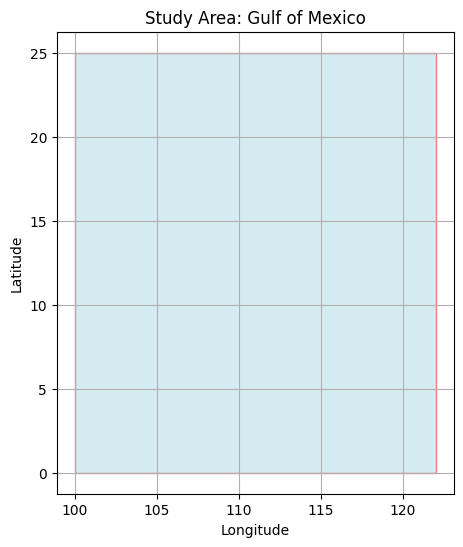

In [22]:
# ============================================================
# EDIT THESE VALUES to define YOUR study area
# ============================================================

# Option A: Simple bounding box (rectangle)
min_lon = 100
min_lat = 0
max_lon = 122
max_lat = 25
study_area_name = "Gulf of Mexico"  # Give your area a name

geometry = box(min_lon, min_lat, max_lon, max_lat)

# ============================================================
# Option B: Custom polygon (for irregular shapes)
# Uncomment below and comment out Option A
# ============================================================
# coords = [
#     (-98.0, 18.0),
#     (-80.0, 18.0),
#     (-80.0, 31.0),
#     (-98.0, 31.0),
#     (-98.0, 18.0),  # must close the polygon
# ]
# geometry = Polygon(coords)

# Create and save shapefile
study_area = gpd.GeoDataFrame(
    {'name': [study_area_name]},
    geometry=[geometry],
    crs="EPSG:4326"
)

study_area.to_file("my_study_area.shp")
print(f"Shapefile saved: my_study_area.shp")
print(f"Study area: {study_area_name}")
print(f"Bounds: {study_area.total_bounds}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, edgecolor='red', facecolor='lightblue', alpha=0.5)
ax.set_title(f"Study Area: {study_area_name}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.grid(True)
plt.show()

In [23]:
# Verify shapefile
study_area = gpd.read_file("my_study_area.shp")
study_area_wgs84 = study_area.to_crs("EPSG:4326")

print("Shapefile information:")
print(study_area_wgs84.head())
print(f"\nCRS: {study_area_wgs84.crs}")
print(f"Bounds: {study_area_wgs84.total_bounds}")
print(f"Area (approx sq degrees): {study_area_wgs84.geometry.area.values[0]:.2f}")

Shapefile information:
             name                                         geometry
0  Gulf of Mexico  POLYGON ((122 0, 100 0, 100 25, 122 25, 122 0))

CRS: EPSG:4326
Bounds: [100.   0. 122.  25.]
Area (approx sq degrees): 550.00


/tmp/ipykernel_7115/2078096370.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"Area (approx sq degrees): {study_area_wgs84.geometry.area.values[0]:.2f}")


## Part 6: Clip Data to Your Study Area

Clip the global datasets down to just your chosen region.

In [24]:
study_area = gpd.read_file("my_study_area.shp")
study_area_wgs84 = study_area.to_crs("EPSG:4326")

def clip_sss_dataset(merged_nc_path, output_path, study_area_gdf, year_label):
    """Load a merged SSS NetCDF, clip to study area, save result."""
    ds = xr.open_dataset(merged_nc_path)
    sss = ds['sss']
    sss = sss.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude')
    sss = sss.rio.write_crs("EPSG:4326")

    clipped = sss.rio.clip(
        study_area_gdf.geometry.values,
        study_area_gdf.crs,
        drop=True
    )

    clipped.to_dataset(name='sss').to_netcdf(output_path)

    original_size = np.prod(sss.shape)
    clipped_size = np.prod(clipped.shape)
    reduction = (1 - clipped_size / original_size) * 100

    print(f"{year_label}: {sss.shape} -> {clipped.shape} ({reduction:.1f}% reduction)")
    print(f"  Saved to: {output_path}")
    return clipped

print("Clipping datasets to study area...\n")
clipped_2015 = clip_sss_dataset(
    "Earth_Data/SSS_2015_merged.nc", "clipped_SSS_2015.nc",
    study_area_wgs84, "2015"
)
print()
clipped_2022 = clip_sss_dataset(
    "Earth_Data/SSS_2022_merged.nc", "clipped_SSS_2022.nc",
    study_area_wgs84, "2022"
)

Clipping datasets to study area...

2015: (720, 1440, 13) -> (100, 88, 13) (99.2% reduction)
  Saved to: clipped_SSS_2015.nc

2022: (720, 1440, 13) -> (100, 88, 13) (99.2% reduction)
  Saved to: clipped_SSS_2022.nc


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


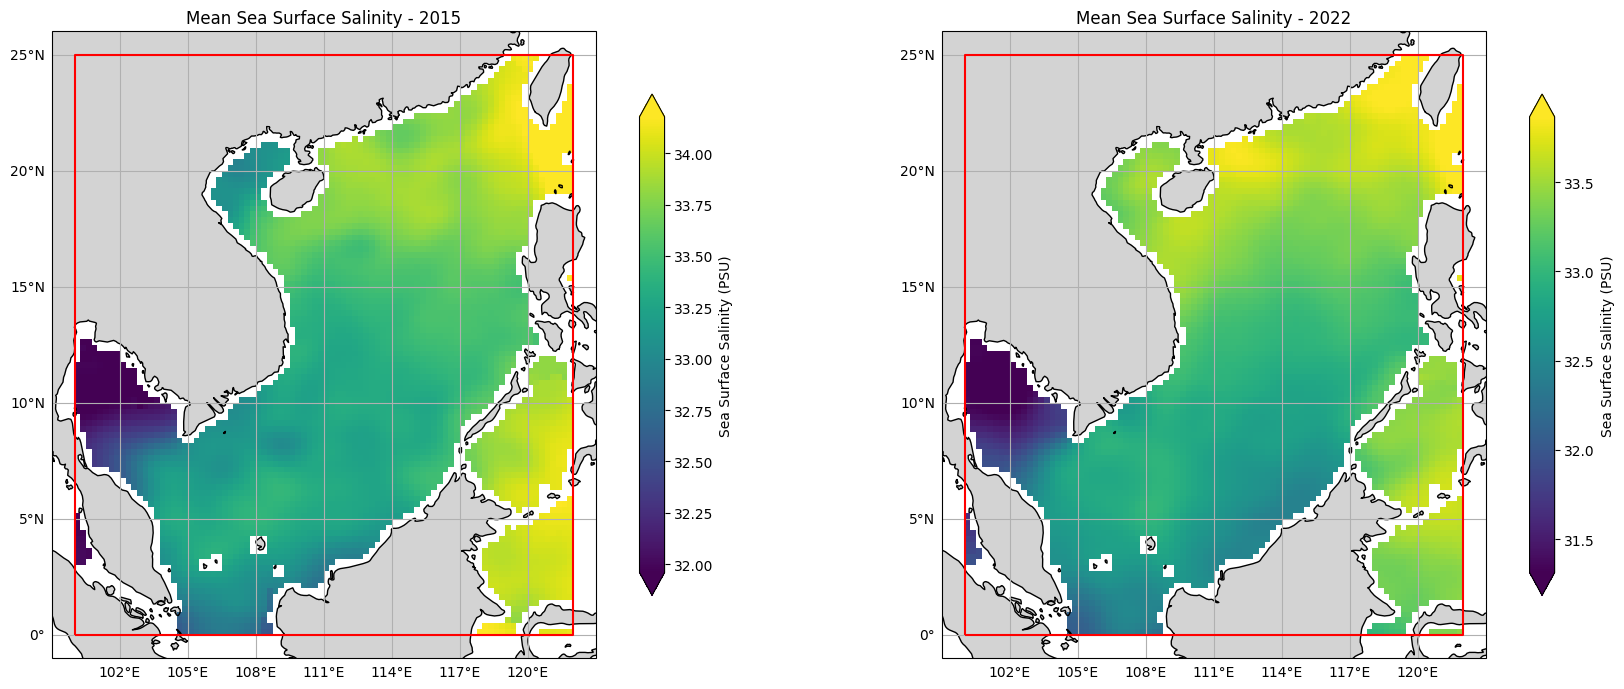

In [25]:
# Visualize both clipped datasets side by side
clipped_2015 = xr.open_dataset("clipped_SSS_2015.nc")['sss']
clipped_2022 = xr.open_dataset("clipped_SSS_2022.nc")['sss']

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

bounds = study_area_wgs84.total_bounds
pad = 1

for ax, data, year in zip(axes, [clipped_2015, clipped_2022], ['2015', '2022']):
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    data.mean('time').plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        robust=True,
        cbar_kwargs={'label': 'Sea Surface Salinity (PSU)', 'shrink': 0.8}
    )

    study_area_wgs84.boundary.plot(
        ax=ax, color='red', linewidth=1.5,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([bounds[0] - pad, bounds[2] + pad,
                   bounds[1] - pad, bounds[3] + pad])
    ax.set_title(f'Mean Sea Surface Salinity - {year}')

plt.tight_layout()
plt.show()

## Part 7: Statistical Analysis

Compare sea surface salinity between 2015 and 2022.

In [26]:
clipped_2015 = xr.open_dataset("clipped_SSS_2015.nc")['sss']
clipped_2022 = xr.open_dataset("clipped_SSS_2022.nc")['sss']

def print_sss_stats(data, label):
    """Compute and print summary statistics for an SSS DataArray."""
    mean_val = float(data.mean(skipna=True))
    median_val = float(data.median(skipna=True))
    std_val = float(data.std(skipna=True))
    min_val = float(data.min(skipna=True))
    max_val = float(data.max(skipna=True))

    print(f"  Mean:               {mean_val:.4f} PSU")
    print(f"  Median:             {median_val:.4f} PSU")
    print(f"  Standard Deviation: {std_val:.4f} PSU")
    print(f"  Minimum:            {min_val:.4f} PSU")
    print(f"  Maximum:            {max_val:.4f} PSU")
    print(f"  Range:              {max_val - min_val:.4f} PSU")
    return mean_val, median_val, std_val

print("=" * 60)
print("SEA SURFACE SALINITY STATISTICS - 2015")
print("=" * 60)
mean_2015, median_2015, std_2015 = print_sss_stats(clipped_2015, "2015")

print("\n" + "=" * 60)
print("SEA SURFACE SALINITY STATISTICS - 2022")
print("=" * 60)
mean_2022, median_2022, std_2022 = print_sss_stats(clipped_2022, "2022")

SEA SURFACE SALINITY STATISTICS - 2015
  Mean:               33.4526 PSU
  Median:             33.4852 PSU
  Standard Deviation: 0.5666 PSU
  Minimum:            30.8840 PSU
  Maximum:            34.9822 PSU
  Range:              4.0983 PSU

SEA SURFACE SALINITY STATISTICS - 2022
  Mean:               33.0338 PSU
  Median:             33.1347 PSU
  Standard Deviation: 0.6400 PSU
  Minimum:            30.1065 PSU
  Maximum:            34.5854 PSU
  Range:              4.4789 PSU


In [27]:
# Compare 2015 vs 2022
print("=" * 60)
print("COMPARISON: 2015 vs 2022")
print("=" * 60)

diff_mean = mean_2022 - mean_2015
diff_median = median_2022 - median_2015
diff_std = std_2022 - std_2015

print(f"  Change in Mean:    {diff_mean:+.4f} PSU")
print(f"  Change in Median:  {diff_median:+.4f} PSU")
print(f"  Change in Std Dev: {diff_std:+.4f} PSU")

if diff_mean > 0:
    print(f"\n  >> Salinity INCREASED by {abs(diff_mean):.4f} PSU on average")
else:
    print(f"\n  >> Salinity DECREASED by {abs(diff_mean):.4f} PSU on average")

COMPARISON: 2015 vs 2022
  Change in Mean:    -0.4188 PSU
  Change in Median:  -0.3505 PSU
  Change in Std Dev: +0.0734 PSU

  >> Salinity DECREASED by 0.4188 PSU on average


Monthly Mean Sea Surface Salinity Comparison:
Month SSS_2015 (PSU) SSS_2022 (PSU) Difference (PSU)
  Jan        35.9205        35.9686          +0.0481
  Feb        35.7764        36.1065          +0.3301
  Mar        35.8050        36.0799          +0.2748
  Apr        35.7275        36.0246          +0.2971
  May        35.8314        35.9395          +0.1081
  Jun        36.1090        35.8049          -0.3040
  Jul        35.9851        35.6501          -0.3350
  Aug        35.7474        35.5135          -0.2338
  Sep        35.7971        35.5117          -0.2854
  Oct        35.9624        35.8170          -0.1454
  Nov        36.0087        35.9183          -0.0903
  Dec        36.0319        35.9055          -0.1264


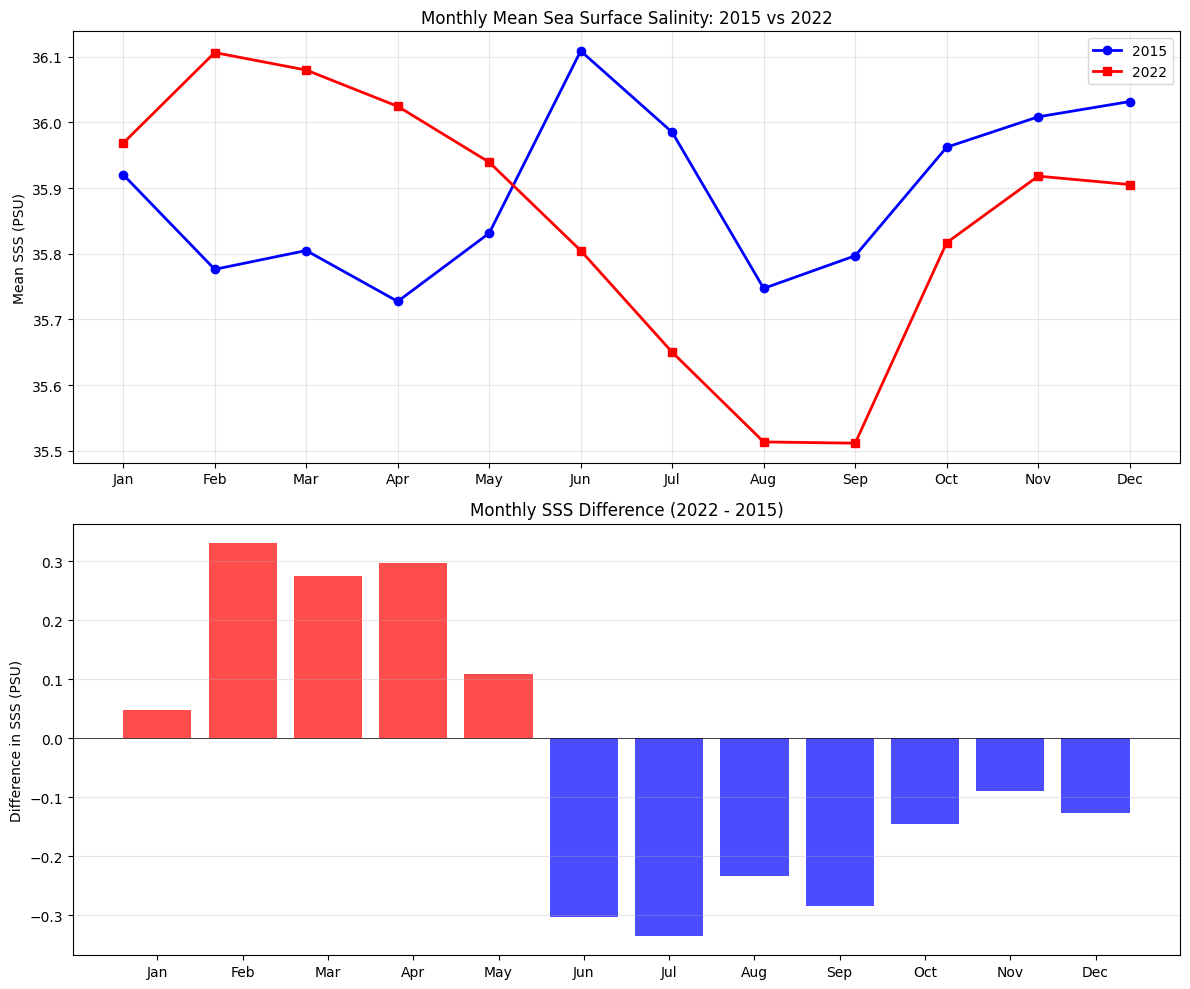

In [20]:
# Monthly comparison
monthly_mean_2015 = clipped_2015.groupby('time.month').mean(skipna=True)
monthly_mean_2022 = clipped_2022.groupby('time.month').mean(skipna=True)

# Only compare months present in BOTH years
common_months = sorted(
    set(monthly_mean_2015.month.values.tolist()) &
    set(monthly_mean_2022.month.values.tolist())
)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

spatial_mean_2015 = [float(monthly_mean_2015.sel(month=m).mean()) for m in common_months]
spatial_mean_2022 = [float(monthly_mean_2022.sel(month=m).mean()) for m in common_months]
labels = [month_names[m - 1] for m in common_months]

comparison_df = pd.DataFrame({
    'Month': labels,
    'SSS_2015 (PSU)': [f"{v:.4f}" for v in spatial_mean_2015],
    'SSS_2022 (PSU)': [f"{v:.4f}" for v in spatial_mean_2022],
    'Difference (PSU)': [f"{(b-a):+.4f}" for a, b in zip(spatial_mean_2015, spatial_mean_2022)]
})

print("Monthly Mean Sea Surface Salinity Comparison:")
print(comparison_df.to_string(index=False))

# Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(labels, spatial_mean_2015, 'b-o', label='2015', linewidth=2)
ax1.plot(labels, spatial_mean_2022, 'r-s', label='2022', linewidth=2)
ax1.set_ylabel('Mean SSS (PSU)')
ax1.set_title('Monthly Mean Sea Surface Salinity: 2015 vs 2022')
ax1.legend()
ax1.grid(True, alpha=0.3)

differences = [b - a for a, b in zip(spatial_mean_2015, spatial_mean_2022)]
colors = ['red' if d > 0 else 'blue' for d in differences]
ax2.bar(labels, differences, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Difference in SSS (PSU)')
ax2.set_title('Monthly SSS Difference (2022 - 2015)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Spatial Statistics of SSS Difference (2022 - 2015):
  Mean difference:   -0.4128 PSU
  Std of difference: 0.2084 PSU
  Max increase:      +0.5051 PSU
  Max decrease:      -1.1907 PSU
  Area with increase: 2.3%
  Area with decrease: 97.7%


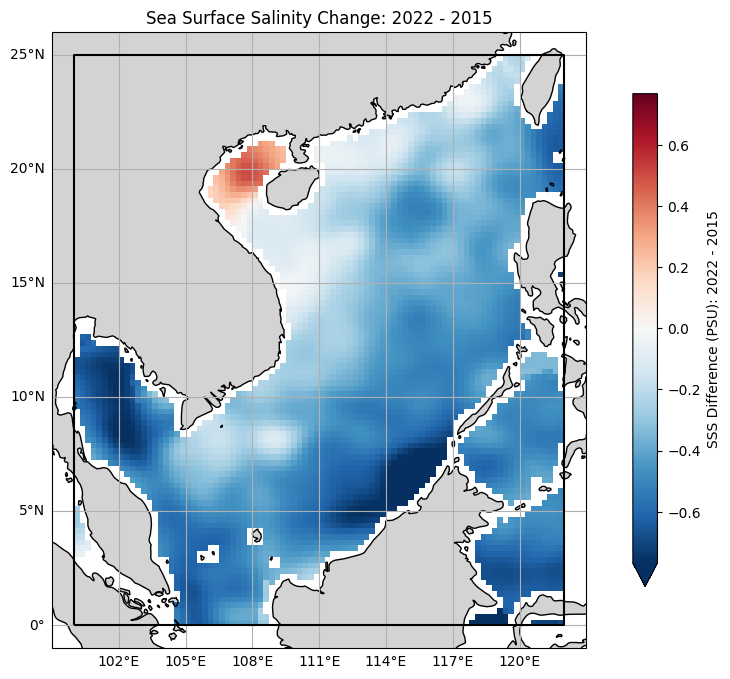

In [28]:
# Spatial difference map
annual_mean_2015 = clipped_2015.mean('time', skipna=True)
annual_mean_2022 = clipped_2022.mean('time', skipna=True)
sss_difference = annual_mean_2022 - annual_mean_2015

print("Spatial Statistics of SSS Difference (2022 - 2015):")
print(f"  Mean difference:   {float(sss_difference.mean(skipna=True)):+.4f} PSU")
print(f"  Std of difference: {float(sss_difference.std(skipna=True)):.4f} PSU")
print(f"  Max increase:      {float(sss_difference.max(skipna=True)):+.4f} PSU")
print(f"  Max decrease:      {float(sss_difference.min(skipna=True)):+.4f} PSU")

valid_cells = float((~sss_difference.isnull()).sum())
if valid_cells > 0:
    increased = float((sss_difference > 0).sum()) / valid_cells * 100
    decreased = float((sss_difference < 0).sum()) / valid_cells * 100
    print(f"  Area with increase: {increased:.1f}%")
    print(f"  Area with decrease: {decreased:.1f}%")

# Plot
study_area_wgs84 = gpd.read_file("my_study_area.shp").to_crs("EPSG:4326")
bounds = study_area_wgs84.total_bounds
pad = 1

fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

sss_difference.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    center=0,
    robust=True,
    cbar_kwargs={'label': 'SSS Difference (PSU): 2022 - 2015', 'shrink': 0.8}
)

study_area_wgs84.boundary.plot(
    ax=ax, color='black', linewidth=1.5,
    transform=ccrs.PlateCarree()
)

ax.set_extent([bounds[0] - pad, bounds[2] + pad,
               bounds[1] - pad, bounds[3] + pad])
ax.set_title('Sea Surface Salinity Change: 2022 - 2015')
plt.show()

---

## References

- [NASA Earth Data](https://earthdata.nasa.gov/)
- [PODAAC OISSS Dataset](https://podaac.jpl.nasa.gov/dataset/OISSS_L4_multimission_monthly_v2)
- [earthaccess Documentation](https://earthaccess.readthedocs.io/)
- [Xarray Documentation](https://xarray.pydata.org/)
- [GeoPandas Documentation](https://geopandas.org/)
- [Rioxarray Documentation](https://corteva.github.io/rioxarray/)
- [Cartopy Documentation](https://scitools.org.uk/cartopy/)